# 1. óra — Statisztikai alapok: élő demók

Ezt a notebookot óra közben vetítjük ki, a `lesson-plan.md`-ben jelzett pontokon.
Nem önálló tananyag — a `slides.md` + `lesson-plan.md` adja a keretet.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

rng = np.random.default_rng(42)
os.makedirs("assets", exist_ok=True)

# a slide-deck sötét zöld/sárgaréz paletájához igazítva, hogy a mentett
# PNG-k ne fehér dobozként üssenek el a diákon
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.facecolor": "#0d2a20",
    "axes.facecolor": "#0d2a20",
    "axes.edgecolor": "#b9c2b3",
    "axes.labelcolor": "#e9e4d2",
    "axes.titlecolor": "#e9e4d2",
    "text.color": "#e9e4d2",
    "xtick.color": "#b9c2b3",
    "ytick.color": "#b9c2b3",
    "grid.color": "#2a4a3a",
    "axes.prop_cycle": plt.cycler(color=["#d1a13a", "#8fb9a8", "#c1543a", "#e9e4d2"]),
    "legend.facecolor": "#123626",
    "legend.edgecolor": "#2a4a3a",
    "legend.labelcolor": "#e9e4d2",
    "savefig.facecolor": "#0d2a20",
})

## 1. Monty Hall — szimuláció

A táblás játék után: fussunk le sok ezer kört, és nézzük meg empirikusan, mennyivel
jobb váltani.

In [2]:
def monty_hall_trial(switch: bool, rng: np.random.Generator) -> bool:
    doors = [0, 0, 0]
    winning_door = rng.integers(3)
    doors[winning_door] = 1

    choice = rng.integers(3)

    # a műsorvezető egy olyan ajtót nyit ki, ami (a) nem a választott, (b) nem a nyertes
    remaining = [d for d in range(3) if d != choice and d != winning_door]
    host_opens = rng.choice(remaining)

    if switch:
        choice = [d for d in range(3) if d != choice and d != host_opens][0]

    return choice == winning_door


n_trials = 20_000
stay_wins = sum(monty_hall_trial(switch=False, rng=rng) for _ in range(n_trials))
switch_wins = sum(monty_hall_trial(switch=True, rng=rng) for _ in range(n_trials))

print(f"Marad, nyerési arány:  {stay_wins / n_trials:.1%}")
print(f"Vált, nyerési arány:   {switch_wins / n_trials:.1%}")

Marad, nyerési arány:  33.3%
Vált, nyerési arány:   66.9%


## 2. Bayes — a teszt paradoxona

Prevalencia 1%, szenzitivitás 99%, specificitás 99%. Pozitív lettél — mekkora
eséllyel vagy tényleg beteg?

In [3]:
prevalence = 0.01
sensitivity = 0.99  # P(pozitív | beteg)
specificity = 0.99  # P(negatív | egészséges)

p_disease = prevalence
p_positive_given_disease = sensitivity
p_positive_given_healthy = 1 - specificity

p_positive = (
    p_positive_given_disease * p_disease
    + p_positive_given_healthy * (1 - p_disease)
)

p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive
print(f"P(beteg | pozitív teszt) = {p_disease_given_positive:.1%}")

P(beteg | pozitív teszt) = 50.0%


## 3. Nagy számok törvénye

Fair érme dobások futó átlaga — nézzük meg, mennyire "esedékes" az írás 8 fej
után (nem az).

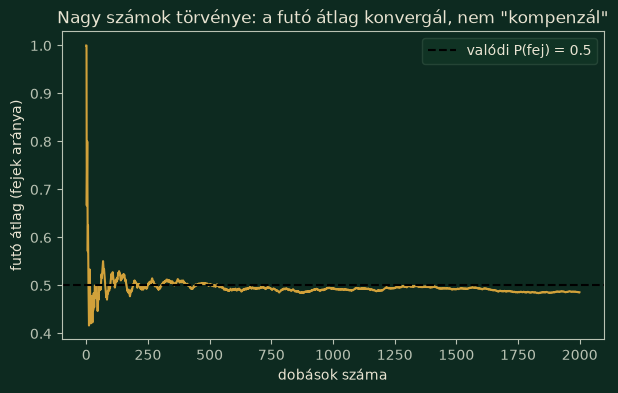

In [4]:
n_flips = 2000
flips = rng.integers(0, 2, size=n_flips)  # 1 = fej
running_mean = np.cumsum(flips) / np.arange(1, n_flips + 1)

plt.plot(running_mean)
plt.axhline(0.5, color="black", linestyle="--", label="valódi P(fej) = 0.5")
plt.xlabel("dobások száma")
plt.ylabel("futó átlag (fejek aránya)")
plt.title("Nagy számok törvénye: a futó átlag konvergál, nem \"kompenzál\"")
plt.legend()
plt.savefig("assets/lln_running_mean.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Centrális határeloszlás-tétel

Erősen ferde (exponenciális) eloszlásból veszünk mintát — és nézzük, milyen alakot
vesz fel a mintaátlagok eloszlása, ahogy n nő.

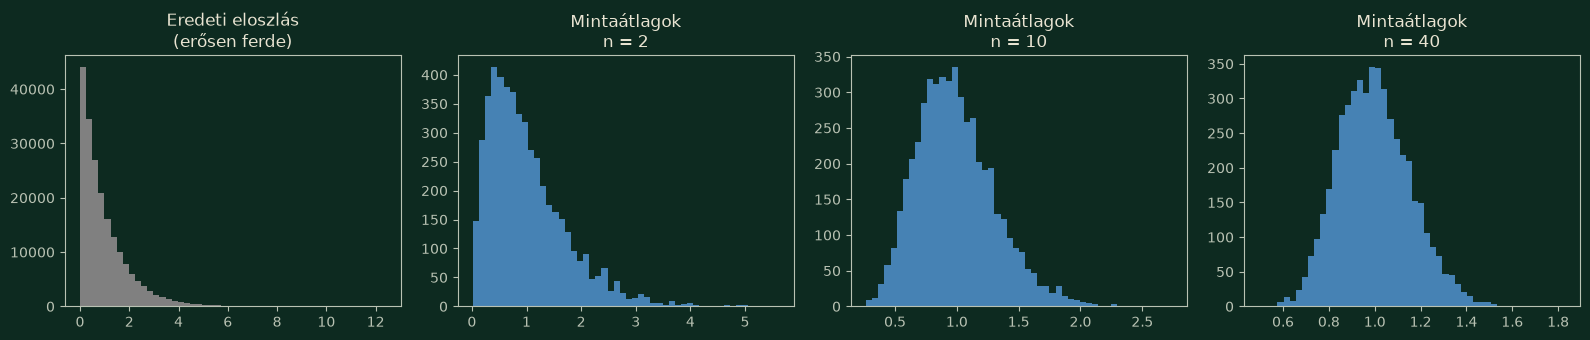

In [5]:
population = rng.exponential(scale=1.0, size=200_000)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

axes[0].hist(population, bins=50, color="grey")
axes[0].set_title("Eredeti eloszlás\n(erősen ferde)")

for ax, n in zip(axes[1:], [2, 10, 40]):
    sample_means = [rng.exponential(scale=1.0, size=n).mean() for _ in range(5000)]
    ax.hist(sample_means, bins=50, color="steelblue")
    ax.set_title(f"Mintaátlagok\nn = {n}")

plt.tight_layout()
plt.savefig("assets/clt_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

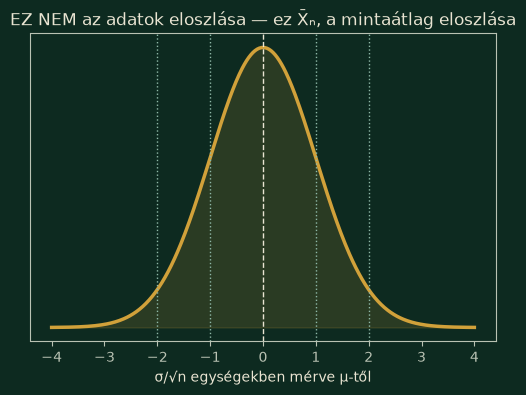

In [6]:
from scipy.stats import norm

x = np.linspace(-4, 4, 400)
mu, sigma = 0, 1  # itt: a mintaátlag (X̄ₙ) mintavételi eloszlásának μ és σ/√n paraméterei

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, norm.pdf(x, mu, sigma), color="#d1a13a", linewidth=2.5)
ax.fill_between(x, norm.pdf(x, mu, sigma), color="#d1a13a", alpha=0.15)
ax.axvline(mu, color="#e9e4d2", linestyle="--", linewidth=1, label="μ")
for k in [1, 2]:
    ax.axvline(mu + k * sigma, color="#8fb9a8", linestyle=":", linewidth=1)
    ax.axvline(mu - k * sigma, color="#8fb9a8", linestyle=":", linewidth=1)
ax.set_title("EZ NEM az adatok eloszlása — ez X̄ₙ, a mintaátlag eloszlása")
ax.set_yticks([])
ax.set_xlabel("σ/√n egységekben mérve μ-től")
plt.savefig("assets/normal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Hipotézisvizsgálat — mit jelent valójában a p-érték?

**Konkrét eset:** a checkers.com teszteli az új regisztrációs oldalt.
- Kontroll (A): 1000 látogatóból 84 regisztrált (8.4%)
- Új verzió (B): 1000 látogatóból 103 regisztrált (10.3%)

Tényleg jobb az új oldal, vagy ez csak véletlen ingadozás? Kétmintás
arány z-próbával: a különbséget a saját szórásához (varianciájához)
viszonyítva mérjük, és abból számoljuk ki a p-értéket.

Kontroll (A): 8.4%
Új verzió (B): 10.3%
Megfigyelt különbség (B - A): +1.9%

p̂ (pooled) = (84 + 103) / (1000 + 1000) = 0.0935
Var(diff) = p̂(1-p̂)(1/n_A + 1/n_B) = 0.000170
SE = √Var = 0.0130
z = diff / SE = 0.019 / 0.0130 = 1.459
p-érték = 2·(1 - Φ(|z|)) = 0.144


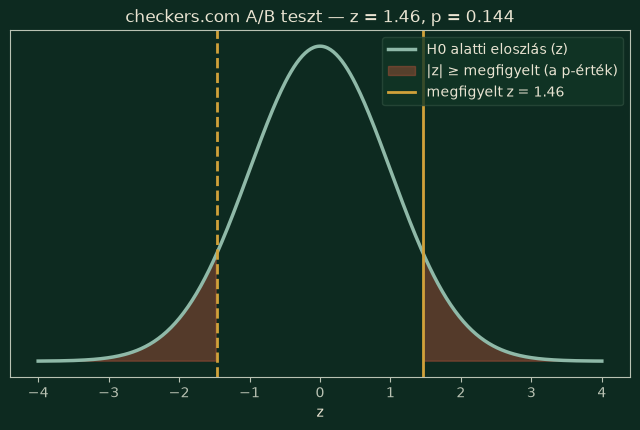

In [7]:
# checkers.com A/B teszt: megfigyelt (nem szimulált) adat
n_a, conversions_a = 1000, 84
n_b, conversions_b = 1000, 103

p_a = conversions_a / n_a
p_b = conversions_b / n_b
observed_diff = p_b - p_a
print(f"Kontroll (A): {p_a:.1%}")
print(f"Új verzió (B): {p_b:.1%}")
print(f"Megfigyelt különbség (B - A): {observed_diff:+.1%}")

# H0 alatt (nincs valódi különbség) a legjobb becslés a KÖZÖS (pooled) arány --
# ezt használjuk a különbség varianciájának becsléséhez
p_pool = (conversions_a + conversions_b) / (n_a + n_b)
variance = p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b)
se = np.sqrt(variance)

z_score = observed_diff / se
p_value = 2 * (1 - norm.cdf(abs(z_score)))

print(f"\np̂ (pooled) = ({conversions_a} + {conversions_b}) / ({n_a} + {n_b}) = {p_pool:.4f}")
print(f"Var(diff) = p̂(1-p̂)(1/n_A + 1/n_B) = {variance:.6f}")
print(f"SE = √Var = {se:.4f}")
print(f"z = diff / SE = {observed_diff:.3f} / {se:.4f} = {z_score:.3f}")
print(f"p-érték = 2·(1 - Φ(|z|)) = {p_value:.3f}")

x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, norm.pdf(x), color="#8fb9a8", linewidth=2.5, label="H0 alatti eloszlás (z)")
ax.fill_between(x, norm.pdf(x), where=(np.abs(x) >= abs(z_score)), color="#c1543a", alpha=0.4, label="|z| ≥ megfigyelt (a p-érték)")
ax.axvline(z_score, color="#d1a13a", linewidth=2, label=f"megfigyelt z = {z_score:.2f}")
ax.axvline(-z_score, color="#d1a13a", linewidth=2, linestyle="--")
ax.set_yticks([])
ax.set_xlabel("z")
ax.set_title(f"checkers.com A/B teszt — z = {z_score:.2f}, p = {p_value:.3f}")
ax.legend()
plt.savefig("assets/checkers_ab_test.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Korreláció vs. kauzalitás

### 6a. Valódi "spurious correlation" — Tyler Vigen adata

Nicolas Cage filmjeinek száma és a fulladásos halálesetek száma az USA-ban,
1980–2013 (forrás: tylervigen.com, r = 0.559 — a valódi, közzétett adat, nem
szimuláció).

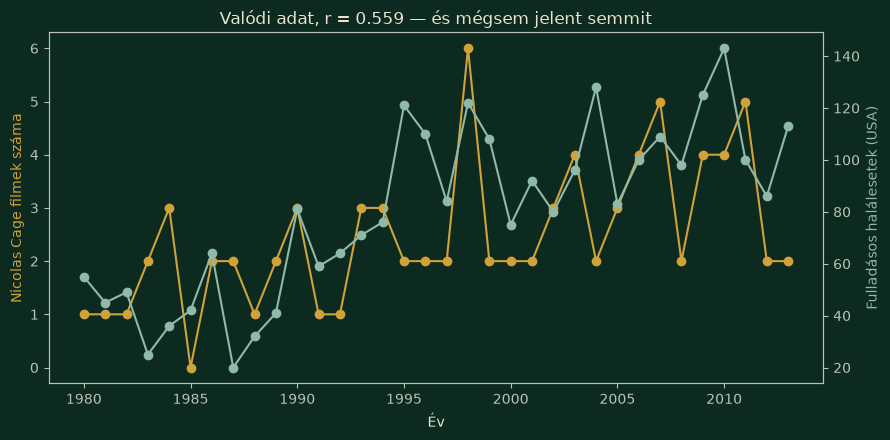

Korrelációs együttható: 0.559


In [8]:
years = list(range(1980, 2014))
cage_movies = [1,1,1,2,3,0,2,2,1,2,3,1,1,3,3,2,2,2,6,2,2,2,3,4,2,3,4,5,2,4,4,5,2,2]
drowning_deaths = [55,45,49,25,36,42,64,20,32,41,81,59,64,71,76,121,110,84,122,108,75,92,80,96,128,83,100,109,98,125,143,100,86,113]

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()

ax1.plot(years, cage_movies, color="#d1a13a", marker="o", label="Nicolas Cage filmek")
ax2.plot(years, drowning_deaths, color="#8fb9a8", marker="o", label="Fulladásos halálesetek")

ax1.set_ylabel("Nicolas Cage filmek száma", color="#d1a13a")
ax2.set_ylabel("Fulladásos halálesetek (USA)", color="#8fb9a8")
ax1.set_xlabel("Év")
r = np.corrcoef(cage_movies, drowning_deaths)[0, 1]
ax1.set_title(f"Valódi adat, r = {r:.3f} — és mégsem jelent semmit")
fig.tight_layout()
plt.savefig("assets/spurious_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Korrelációs együttható: {r:.3f}")

### 6b. Konfounder demó — fagylaltfogyasztás és vízbefulladások

Itt már szintetikus adat: együtt mozognak, de nincs közöttük közvetlen
ok-okozat — a közös ok a hőmérséklet.

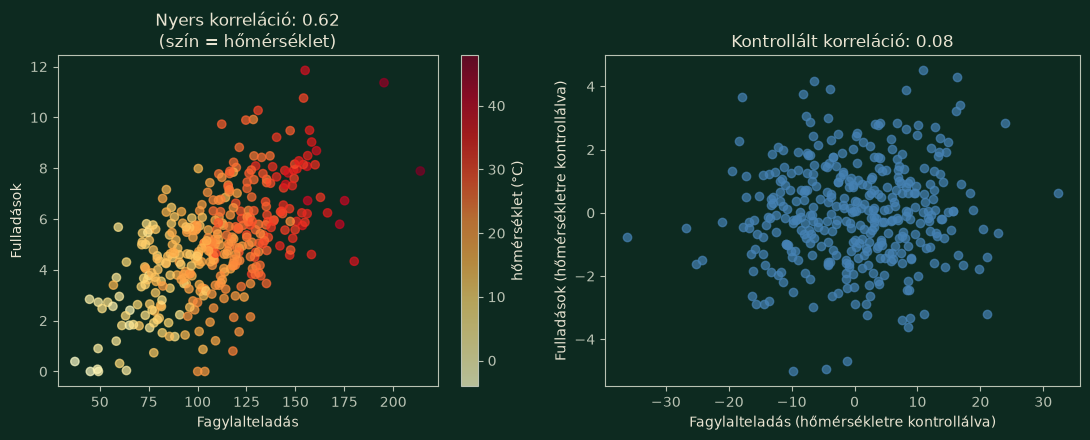

Nyers korreláció (fagyi vs. fulladás): 0.62
Korreláció hőmérsékletre kontrollálva: 0.08


In [9]:
n_days = 365
temperature = rng.normal(20, 8, size=n_days)

ice_cream_sales = 50 + 3 * temperature + rng.normal(0, 10, size=n_days)
drownings = 2 + 0.15 * temperature + rng.normal(0, 1.5, size=n_days)
drownings = np.clip(drownings, 0, None)

df = pd.DataFrame({
    "temperature": temperature,
    "ice_cream_sales": ice_cream_sales,
    "drownings": drownings,
})

raw_corr = df["ice_cream_sales"].corr(df["drownings"])

resid_ice_cream = df["ice_cream_sales"] - LinearRegression().fit(
    df[["temperature"]], df["ice_cream_sales"]
).predict(df[["temperature"]])
resid_drownings = df["drownings"] - LinearRegression().fit(
    df[["temperature"]], df["drownings"]
).predict(df[["temperature"]])
controlled_corr = np.corrcoef(resid_ice_cream, resid_drownings)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc = axes[0].scatter(df["ice_cream_sales"], df["drownings"], c=df["temperature"], cmap="YlOrRd", alpha=0.7)
axes[0].set_xlabel("Fagylalteladás")
axes[0].set_ylabel("Fulladások")
axes[0].set_title(f"Nyers korreláció: {raw_corr:.2f}\n(szín = hőmérséklet)")
plt.colorbar(sc, ax=axes[0], label="hőmérséklet (°C)")

axes[1].scatter(resid_ice_cream, resid_drownings, color="steelblue", alpha=0.7)
axes[1].set_xlabel("Fagylalteladás (hőmérsékletre kontrollálva)")
axes[1].set_ylabel("Fulladások (hőmérsékletre kontrollálva)")
axes[1].set_title(f"Kontrollált korreláció: {controlled_corr:.2f}")

plt.tight_layout()
plt.savefig("assets/confounder_demo.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Nyers korreláció (fagyi vs. fulladás): {raw_corr:.2f}")
print(f"Korreláció hőmérsékletre kontrollálva: {controlled_corr:.2f}")

## 7. Simpson-paradoxon — UC Berkeley-stílusú toy példa

Szintetikus felvételi adat két tanszékkel. Nézzük meg az összesített és a
tanszékenkénti arányokat.

férfi összesített = (800×60% + 200×30%) / 1000 = 54.0%
nő összesített     = (200×65% + 800×35%) / 1000 = 41.0%


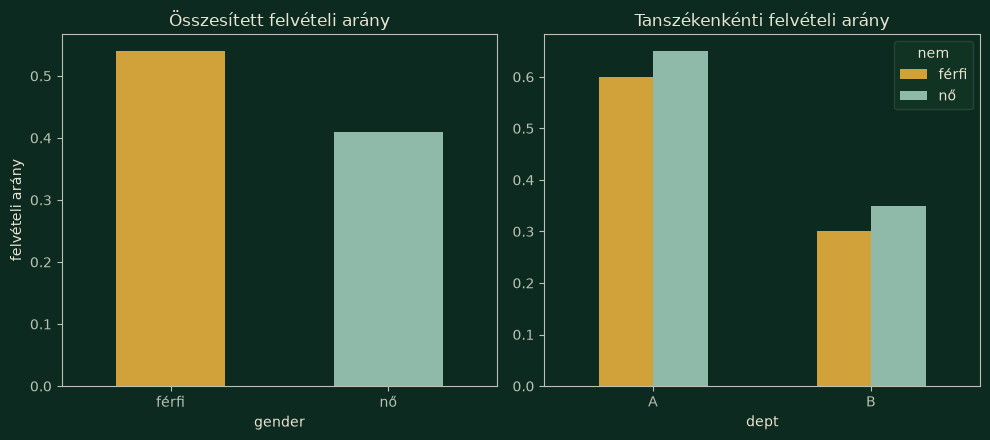


Összesített felvételi arány nemenként:
gender
férfi    0.54
nő       0.41
Name: admitted, dtype: float64

Tanszékenkénti felvételi arány:
gender  férfi    nő
dept               
A         0.6  0.65
B         0.3  0.35

Jelentkezők száma tanszékenként:
gender  férfi   nő
dept              
A         800  200
B         200  800


In [10]:
# Determinisztikus (nem véletlen mintavételezett) admissziós számok -- a
# konkrét arányokat a diákon is idézzük, ezért nem szeretnénk, hogy egy
# véletlen húzás zajszintje (kis n-nél könnyen megtörténhet) elforgassa
# az irányt egy-egy alcsoportban.
admissions = pd.DataFrame({
    "dept": ["A"] * 800 + ["A"] * 200 + ["B"] * 200 + ["B"] * 800,
    "gender": ["férfi"] * 800 + ["nő"] * 200 + ["férfi"] * 200 + ["nő"] * 800,
    # A tanszék (könnyű): a férfiak nagy része IDE jelentkezik
    # B tanszék (versenyzett, nehéz): a nők nagy része IDE jelentkezik
    "admitted": (
        [1] * 480 + [0] * (800 - 480)   # férfi, A tanszék: 60%
        + [1] * 130 + [0] * (200 - 130)  # nő, A tanszék: 65%
        + [1] * 60 + [0] * (200 - 60)    # férfi, B tanszék: 30%
        + [1] * 280 + [0] * (800 - 280)  # nő, B tanszék: 35%
    ),
})

overall = admissions.groupby("gender")["admitted"].mean()
by_dept = admissions.groupby(["dept", "gender"])["admitted"].mean().unstack()
counts = admissions.groupby(["dept", "gender"]).size().unstack()

# a "paradoxon" nem más, mint egy súlyozott átlag: a nők a NEHÉZ tanszékre
# jelentkeznek nagyobb arányban, ezért az összesített rátájukat lehúzza
# a tanszék önmagában alacsony felvételi aránya - annak ellenére, hogy
# MINDKÉT tanszéken jobb arányban vették fel őket, mint a férfiakat
weighted_calc = (
    f"férfi összesített = ({counts.loc['A','férfi']}×{by_dept.loc['A','férfi']:.0%} + "
    f"{counts.loc['B','férfi']}×{by_dept.loc['B','férfi']:.0%}) / "
    f"{counts.loc['A','férfi']+counts.loc['B','férfi']} = {overall['férfi']:.1%}\n"
    f"nő összesített     = ({counts.loc['A','nő']}×{by_dept.loc['A','nő']:.0%} + "
    f"{counts.loc['B','nő']}×{by_dept.loc['B','nő']:.0%}) / "
    f"{counts.loc['A','nő']+counts.loc['B','nő']} = {overall['nő']:.1%}"
)
print(weighted_calc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

overall.plot.bar(ax=axes[0], color=["#d1a13a", "#8fb9a8"])
axes[0].set_title("Összesített felvételi arány")
axes[0].set_ylabel("felvételi arány")
axes[0].set_xticklabels(overall.index, rotation=0)

by_dept.plot.bar(ax=axes[1], color=["#d1a13a", "#8fb9a8"])
axes[1].set_title("Tanszékenkénti felvételi arány")
axes[1].set_xticklabels(by_dept.index, rotation=0)
axes[1].legend(title="nem")

plt.tight_layout()
plt.savefig("assets/simpsons_paradox.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nÖsszesített felvételi arány nemenként:")
print(overall.round(3))
print("\nTanszékenkénti felvételi arány:")
print(by_dept.round(2))
print("\nJelentkezők száma tanszékenként:")
print(counts)

## 8. Dimenzió-átok

Véletlenszerű pontok egységkockában, növekvő dimenziószámmal — nézzük, hogyan
tűnik el a különbség a legközelebbi és legtávolabbi szomszéd távolsága között.

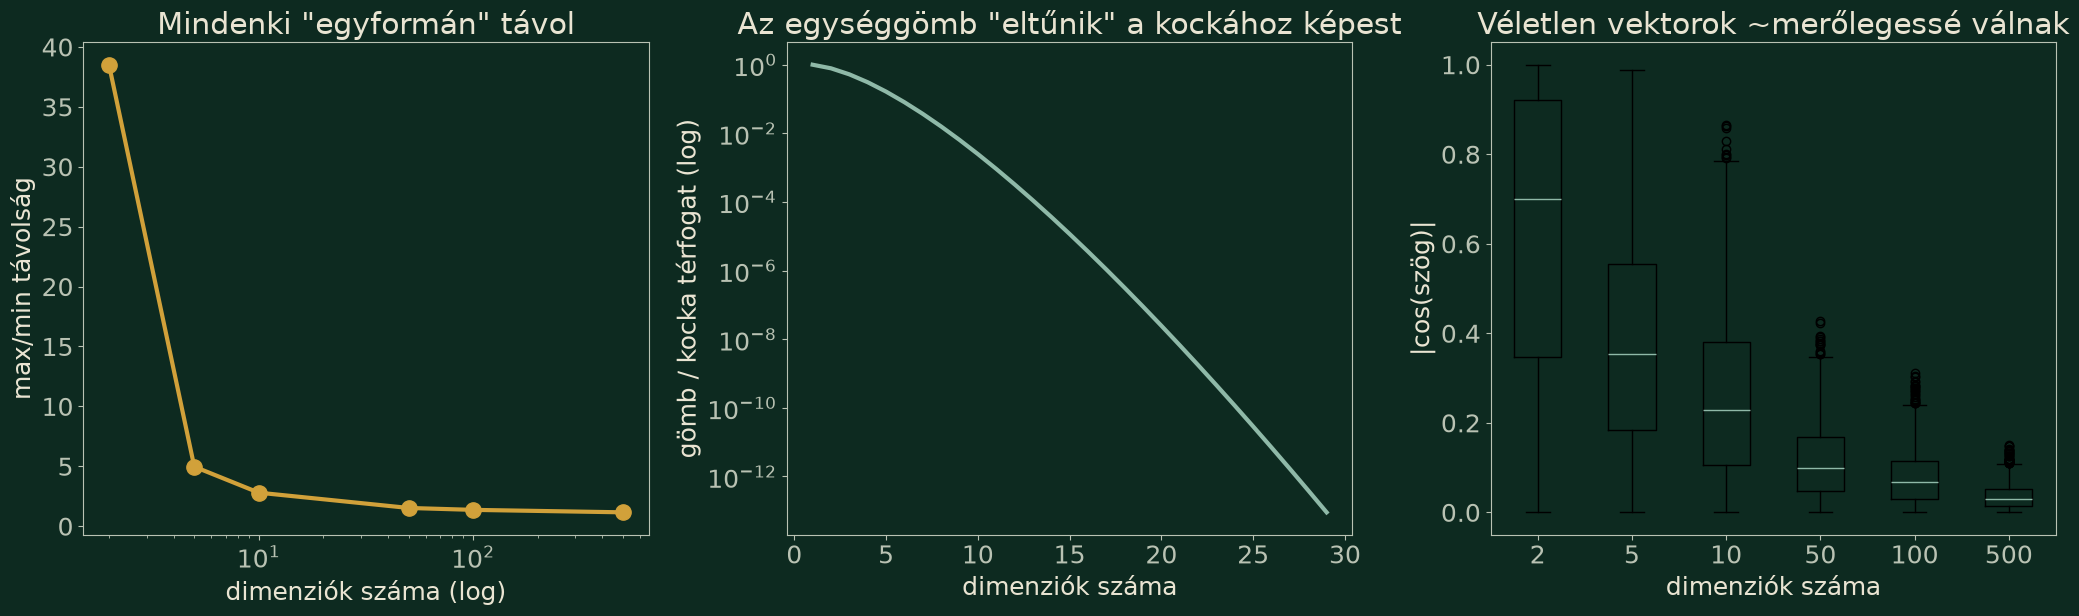

Gömb/kocka térfogatarány d=10 esetén: 2.49e-03
Átlagos |cos(szög)| d=500 esetén: 0.0363


In [11]:
from scipy.special import gamma as gamma_fn

n_points = 1000
dimensions = [2, 5, 10, 50, 100, 500]
ratios = []

for d in dimensions:
    points = rng.uniform(0, 1, size=(n_points, d))
    origin = np.zeros(d)
    distances = np.linalg.norm(points - origin, axis=1)
    ratios.append(distances.max() / distances.min())

# gömb/kocka térfogat-arány: az egységgömb térfogata / a körülírt kocka térfogata
dims_fine = np.arange(1, 30)
ball_volume = np.pi ** (dims_fine / 2) / gamma_fn(dims_fine / 2 + 1)  # sugár = 1
cube_volume = 2.0 ** dims_fine  # oldal = 2 (a gömböt körülírva)
volume_ratio = ball_volume / cube_volume

# két véletlen egységvektor szöge/koszinusza növekvő dimenzióban
cosines_by_dim = []
for d in dimensions:
    a = rng.normal(size=(2000, d))
    b = rng.normal(size=(2000, d))
    a /= np.linalg.norm(a, axis=1, keepdims=True)
    b /= np.linalg.norm(b, axis=1, keepdims=True)
    cosines_by_dim.append(np.abs(np.sum(a * b, axis=1)))

# széles, 3-oszlopos elrendezés, nagy fontokkal -- ez a slide-on teljes
# szélességben, a szöveg ALATT jelenik meg, úgyhogy a szélesség van bőven
plt.rcParams.update({"font.size": 18})
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))

axes[0].plot(dimensions, ratios, marker="o", color="#d1a13a", linewidth=3, markersize=11)
axes[0].set_xscale("log")
axes[0].set_xlabel("dimenziók száma (log)")
axes[0].set_ylabel("max/min távolság")
axes[0].set_title("Mindenki \"egyformán\" távol")

axes[1].plot(dims_fine, volume_ratio, color="#8fb9a8", linewidth=3)
axes[1].set_yscale("log")
axes[1].set_xlabel("dimenziók száma")
axes[1].set_ylabel("gömb / kocka térfogat (log)")
axes[1].set_title("Az egységgömb \"eltűnik\" a kockához képest")

axes[2].boxplot(cosines_by_dim, tick_labels=dimensions)
axes[2].set_xlabel("dimenziók száma")
axes[2].set_ylabel("|cos(szög)|")
axes[2].set_title("Véletlen vektorok ~merőlegessé válnak")

plt.tight_layout()
plt.savefig("assets/curse_of_dimensionality.png", dpi=150, bbox_inches="tight")
plt.show()
plt.rcParams.update({"font.size": 10})

print(f"Gömb/kocka térfogatarány d=10 esetén: {ball_volume[9] / cube_volume[9]:.2e}")
print(f"Átlagos |cos(szög)| d=500 esetén: {cosines_by_dim[-1].mean():.4f}")

## 9. Lineáris regresszió

Egyszerű szintetikus adat, legkisebb négyzetek illesztés.

Illesztett egyenes: ŷ = 4.68 + 2.61 · x
R² = 0.88


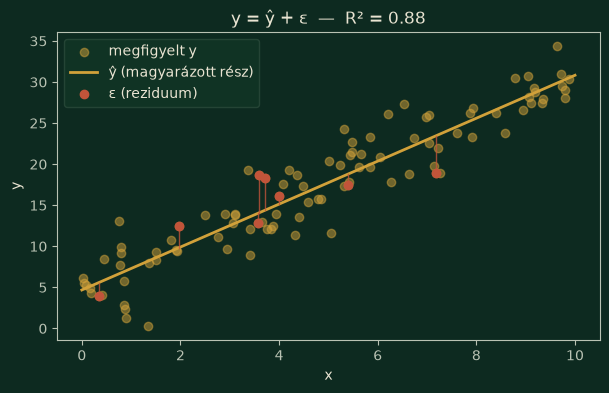

In [12]:
x = rng.uniform(0, 10, size=100)
y = 2.5 * x + 5 + rng.normal(0, 3, size=100)

model = LinearRegression().fit(x.reshape(-1, 1), y)
y_pred = model.predict(x.reshape(-1, 1))
r_squared = model.score(x.reshape(-1, 1), y)
print(f"Illesztett egyenes: ŷ = {model.intercept_:.2f} + {model.coef_[0]:.2f} · x")
print(f"R² = {r_squared:.2f}")

plt.scatter(x, y, alpha=0.5, label="megfigyelt y")
x_line = np.linspace(0, 10, 100)
plt.plot(x_line, model.predict(x_line.reshape(-1, 1)), color="#d1a13a", label="ŷ (magyarázott rész)", linewidth=2)

# reziduumok (hiba/ε) berajzolása néhány pontra
highlight_idx = rng.choice(len(x), size=8, replace=False)
for i in highlight_idx:
    plt.plot([x[i], x[i]], [y_pred[i], y[i]], color="#c1543a", linewidth=1, alpha=0.8)
plt.scatter(x[highlight_idx], y[highlight_idx], color="#c1543a", zorder=5, label="ε (reziduum)")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"y = ŷ + ε  —  R² = {r_squared:.2f}")
plt.legend()
plt.savefig("assets/linear_regression.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Lineáris valószínűségi modell → logisztikus regresszió

Bináris kimenet (pl. lemorzsolódás) — előbb megpróbáljuk lineáris regresszióval
(LPM), aztán megnézzük, hol romlik el, és áttérünk logisztikus regresszióra.

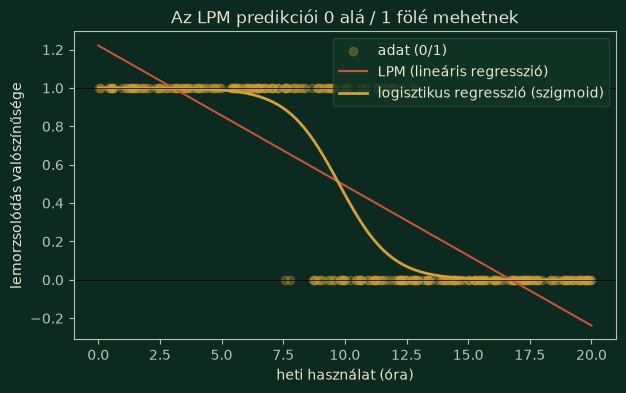

LPM predikció min/max: -0.24 / 1.22
Logisztikus predikció min/max: 0.00 / 1.00

logit(p) = 9.237 + -0.946 · usage_hours
béta (log-odds/óra) = -0.946
e^béta (odds ratio/óra) = 0.388  ->  minden plusz heti óra a lemorzsolódás esélyét (odds) 39%-ára viszi


In [13]:
usage_hours = rng.uniform(0, 20, size=300)
# minél kevesebbet használja, annál nagyobb eséllyel morzsolódik le
churn_prob_true = 1 / (1 + np.exp(usage_hours - 10))
churned = rng.binomial(1, churn_prob_true)

lpm = LinearRegression().fit(usage_hours.reshape(-1, 1), churned)
logit = LogisticRegression().fit(usage_hours.reshape(-1, 1), churned)

x_line = np.linspace(0, 20, 200).reshape(-1, 1)
lpm_pred = lpm.predict(x_line)
logit_pred = logit.predict_proba(x_line)[:, 1]

plt.scatter(usage_hours, churned, alpha=0.3, label="adat (0/1)")
plt.plot(x_line, lpm_pred, color="#c1543a", label="LPM (lineáris regresszió)")
plt.plot(x_line, logit_pred, color="#d1a13a", label="logisztikus regresszió (szigmoid)", linewidth=2)
plt.axhline(0, color="black", linewidth=0.5)
plt.axhline(1, color="black", linewidth=0.5)
plt.xlabel("heti használat (óra)")
plt.ylabel("lemorzsolódás valószínűsége")
plt.legend()
plt.title("Az LPM predikciói 0 alá / 1 fölé mehetnek")
plt.savefig("assets/lpm_vs_logistic.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"LPM predikció min/max: {lpm_pred.min():.2f} / {lpm_pred.max():.2f}")
print(f"Logisztikus predikció min/max: {logit_pred.min():.2f} / {logit_pred.max():.2f}")

beta0, beta1 = logit.intercept_[0], logit.coef_[0][0]
odds_ratio = np.exp(beta1)
print(f"\nlogit(p) = {beta0:.3f} + {beta1:.3f} · usage_hours")
print(f"béta (log-odds/óra) = {beta1:.3f}")
print(f"e^béta (odds ratio/óra) = {odds_ratio:.3f}  ->  minden plusz heti óra a lemorzsolódás esélyét (odds) {odds_ratio:.0%}-ára viszi")